# Week 5 — Stock Price Prediction using LSTM (Part 1)

Predicts the **next 15 units** of a stock's adjusted closing price with an
LSTM network trained on the adjusted close plus two technical indicators
(**MACD** and **RSI**).

**Pipeline**

1. **Data collection** — user inputs (ticker, dates, timeframe) → `yfinance`
2. **Visualization** — adjusted close + Bollinger Bands, MACD, RSI
3. **Preprocessing** — MinMax scaling, 60-step sliding windows, 80/20 chronological split
4. **Model** — stacked LSTM (64 → 32) with dropout, built in TensorFlow/Keras
5. **Prediction** — test-set evaluation (R² score) and a recursive 15-step forecast

All plots are also saved as PNG files next to this notebook.

In [1]:
%matplotlib inline
import os
import sys
import warnings

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")  # quiet TensorFlow logs
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from cycler import cycler
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Sequential

np.random.seed(42)
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()  # reproducible training runs

print("TensorFlow", tf.__version__, "| yfinance", yf.__version__)

/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


2026-07-05 03:10:45.618231: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783201245.630535  127423 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783201245.634110  127423 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783201245.643358  127423 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783201245.643375  127423 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783201245.643380  127423 computation_placer.cc:177] computation placer alr

TensorFlow 2.19.0 | yfinance 1.4.1


In [2]:
# Plot styling: consistent palette, thin marks, recessive grid
COLORS = {
    "blue": "#2a78d6",    # series 1
    "aqua": "#1baf7a",    # series 2
    "yellow": "#eda100",  # series 3
    "green": "#008300",   # series 4
    "violet": "#4a3aa7",  # series 5
    "red": "#e34948",     # series 6
}

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelcolor": "#52514e",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "text.color": "#0b0b0b",
    "lines.linewidth": 2.0,
    "axes.prop_cycle": cycler(color=list(COLORS.values())),
    "figure.figsize": (12, 5),
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "legend.frameon": False,
})


def save_fig(fig, name):
    """Save a copy of the figure next to the notebook."""
    fig.savefig(name)
    print(f"saved plot -> {name}")

## Task 1 — Data Collection

The notebook prompts for the stock ticker, date range and timeframe.
When run non-interactively (e.g. *Run All* through a headless executor)
the defaults in brackets are used automatically.

In [3]:
TIMEFRAMES = {"daily": "1d", "weekly": "1wk", "monthly": "1mo"}


def ask(prompt, default):
    """Prompt the user, falling back to the default when stdin is unavailable."""
    try:
        value = input(f"{prompt} [{default}]: ").strip()
        return value if value else default
    except Exception:
        print(f"{prompt} [{default}]: (input unavailable, using default)")
        return default


TICKER = ask("Stock ticker (e.g. AAPL, GOOGL)", "AAPL").upper()
START = ask("Start date (YYYY-MM-DD)", "2018-01-01")
END = ask("End date (YYYY-MM-DD)", "2026-01-01")
TIMEFRAME = ask("Timeframe (daily / weekly / monthly)", "daily").lower()
assert TIMEFRAME in TIMEFRAMES, f"timeframe must be one of {list(TIMEFRAMES)}"

Stock ticker (e.g. AAPL, GOOGL) [AAPL]: (input unavailable, using default)
Start date (YYYY-MM-DD) [2018-01-01]: (input unavailable, using default)
End date (YYYY-MM-DD) [2026-01-01]: (input unavailable, using default)
Timeframe (daily / weekly / monthly) [daily]: (input unavailable, using default)


In [4]:
print(f"Downloading {TICKER} ({TIMEFRAME}) from {START} to {END} ...")
df = yf.download(TICKER, start=START, end=END, interval=TIMEFRAMES[TIMEFRAME],
                 auto_adjust=False, progress=False)
assert not df.empty, "No data returned - check the ticker and dates."

# yfinance returns MultiIndex columns (price, ticker) for single tickers
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)
if "Adj Close" not in df.columns:
    df["Adj Close"] = df["Close"]

print(f"Downloaded {len(df)} rows.")
df.tail()

Downloaded 2011 rows.


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2025-12-24,273.302216,273.809998,275.429993,272.200012,272.339996,17910600
2025-12-26,272.893005,273.399994,275.369995,272.859985,274.160004,21521800
2025-12-29,273.252350,273.760010,274.359985,272.350006,272.690002,23715200
2025-12-30,272.573547,273.079987,274.079987,272.279999,272.809998,22139600
2025-12-31,271.355835,271.859985,273.679993,271.750000,273.059998,27293600


## Task 2 — Technical Indicators & Visualization

* **MACD** (Moving Average Convergence Divergence) — difference between the
  12- and 26-period EMAs, with a 9-period EMA *signal line*. Captures trend
  direction and momentum; crossovers are classic buy/sell signals.
* **RSI** (Relative Strength Index, 14) — momentum oscillator in [0, 100];
  above 70 the stock is considered *overbought*, below 30 *oversold*.
* **Bollinger Bands** (20-period SMA ± 2σ) — volatility envelope, plotted for
  context alongside the adjusted close.

In [5]:
def compute_macd(close, fast=12, slow=26, signal=9):
    """MACD = EMA(fast) - EMA(slow); signal = EMA(MACD, signal)."""
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=signal, adjust=False).mean()
    return macd, macd_signal, macd - macd_signal


def compute_rsi(close, period=14):
    """Relative Strength Index using Wilder's smoothing."""
    delta = close.diff()
    gain = delta.clip(lower=0).ewm(alpha=1 / period, adjust=False).mean()
    loss = (-delta.clip(upper=0)).ewm(alpha=1 / period, adjust=False).mean()
    rs = gain / loss
    return 100 - 100 / (1 + rs)


def compute_bollinger(close, period=20, num_std=2):
    mid = close.rolling(period).mean()
    std = close.rolling(period).std()
    return mid, mid + num_std * std, mid - num_std * std


close = df["Adj Close"]
df["MACD"], df["MACD_signal"], df["MACD_hist"] = compute_macd(close)
df["RSI"] = compute_rsi(close)
df["BB_mid"], df["BB_upper"], df["BB_lower"] = compute_bollinger(close)
df[["Adj Close", "MACD", "RSI"]].describe().round(2)

Price,Adj Close,MACD,RSI
count,2011.00,2011.00,2010.00
mean,135.27,0.81,55.27
std,66.69,2.68,12.85
min,33.74,-10.57,0.00
25%,64.27,-0.86,45.27
50%,142.68,0.80,56.23
75%,182.62,2.49,64.96
max,285.66,8.88,88.26


saved plot -> 01_price_bollinger.png


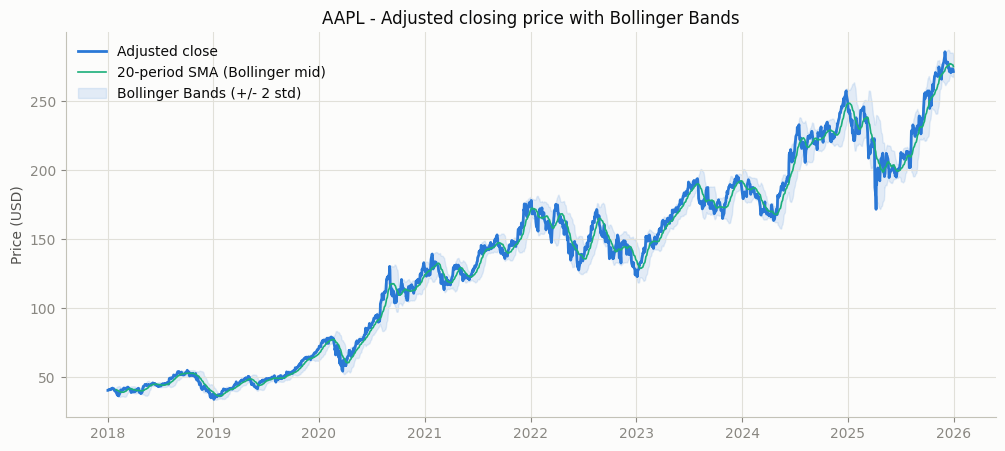

In [6]:
fig, ax = plt.subplots()
ax.plot(df.index, df["Adj Close"], color=COLORS["blue"], label="Adjusted close")
ax.plot(df.index, df["BB_mid"], color=COLORS["aqua"], linewidth=1.2,
        label="20-period SMA (Bollinger mid)")
ax.fill_between(df.index, df["BB_lower"], df["BB_upper"],
                color=COLORS["blue"], alpha=0.12,
                label="Bollinger Bands (+/- 2 std)")
ax.set_title(f"{TICKER} - Adjusted closing price with Bollinger Bands")
ax.set_ylabel("Price (USD)")
ax.legend()
save_fig(fig, "01_price_bollinger.png")
plt.show()

saved plot -> 02_macd.png


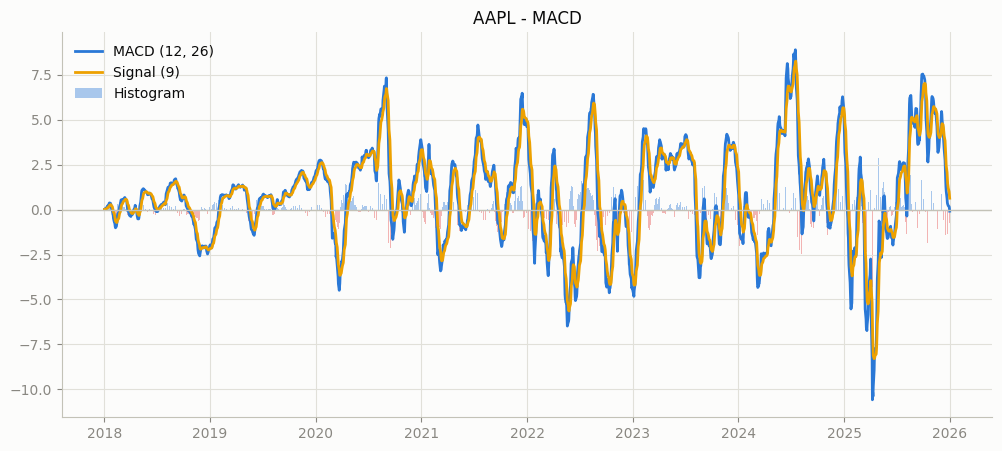

In [7]:
fig, ax = plt.subplots()
ax.plot(df.index, df["MACD"], color=COLORS["blue"], label="MACD (12, 26)")
ax.plot(df.index, df["MACD_signal"], color=COLORS["yellow"], label="Signal (9)")
hist_colors = np.where(df["MACD_hist"] >= 0, COLORS["blue"], COLORS["red"])
ax.bar(df.index, df["MACD_hist"], color=hist_colors, alpha=0.4, width=1.0,
       label="Histogram")
ax.axhline(0, color="#c3c2b7", linewidth=1)
ax.set_title(f"{TICKER} - MACD")
ax.legend()
save_fig(fig, "02_macd.png")
plt.show()

saved plot -> 03_rsi.png


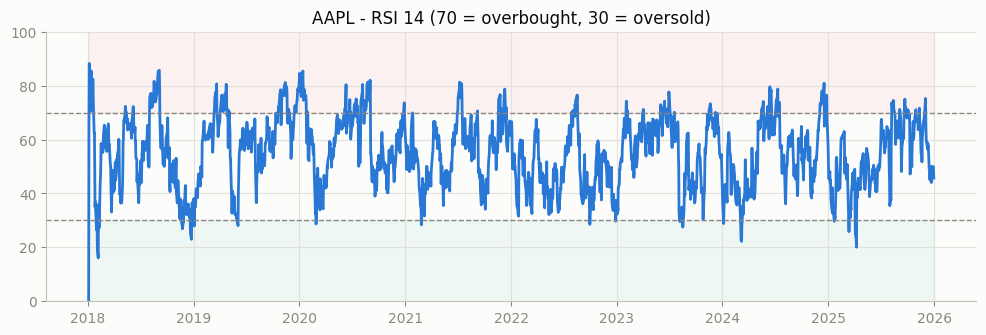

In [8]:
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(df.index, df["RSI"], color=COLORS["blue"])
ax.axhline(70, color="#898781", linewidth=1, linestyle="--")
ax.axhline(30, color="#898781", linewidth=1, linestyle="--")
ax.fill_between(df.index, 70, 100, color=COLORS["red"], alpha=0.06)
ax.fill_between(df.index, 0, 30, color=COLORS["aqua"], alpha=0.06)
ax.set_ylim(0, 100)
ax.set_title(f"{TICKER} - RSI 14 (70 = overbought, 30 = oversold)")
save_fig(fig, "03_rsi.png")
plt.show()

## Task 3 — Data Preprocessing

* Features: **Adj Close, MACD, RSI** — scaled to [0, 1] with `MinMaxScaler`
  (a separate scaler for the target so predictions can be inverted cleanly).
* Sliding windows of the past **60** steps predict the next step's close.
* Chronological **80/20** train/test split — no shuffling, so the model is
  always evaluated on data that lies strictly in its future.

In [9]:
FEATURES = ["Adj Close", "MACD", "RSI"]
WINDOW = min(60, max(10, len(df) // 5))  # shrinks for short weekly/monthly sets

data = df[FEATURES].dropna()
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()
scaled_features = feature_scaler.fit_transform(data.values)
scaled_target = target_scaler.fit_transform(data[["Adj Close"]].values).ravel()


def make_sequences(features, target, window):
    X, y = [], []
    for i in range(window, len(features)):
        X.append(features[i - window:i])
        y.append(target[i])
    return np.array(X), np.array(y)


X, y = make_sequences(scaled_features, scaled_target, WINDOW)
split = int(len(X) * 0.8)  # chronological split - no shuffling
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

print(f"Sequences: {X.shape[0]} windows of {WINDOW} steps x {X.shape[2]} features")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Sequences: 1950 windows of 60 steps x 3 features
Train: (1560, 60, 3), Test: (390, 60, 3)


## Task 4 — Build & Train the LSTM Model

Stacked LSTM (64 → 32 units) with dropout for regularisation and a single
linear output for the next scaled close. Early stopping on a 10 % validation
tail restores the best weights.

In [10]:
model = Sequential([
    Input(shape=(WINDOW, len(FEATURES))),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1),
])
model.compile(optimizer="adam", loss="mse")
model.summary()

2026-07-05 03:10:51.347181: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40


2026-07-05 03:10:51.530959: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


44/44 - 2s - 52ms/step - loss: 0.0109 - val_loss: 7.9201e-04


Epoch 2/40


44/44 - 1s - 23ms/step - loss: 0.0030 - val_loss: 0.0017


...

Epoch 38/40


44/44 - 1s - 24ms/step - loss: 7.0401e-04 - val_loss: 6.2091e-04


Epoch 39/40


44/44 - 1s - 25ms/step - loss: 7.8837e-04 - val_loss: 2.4247e-04


saved plot -> 04_training_loss.png


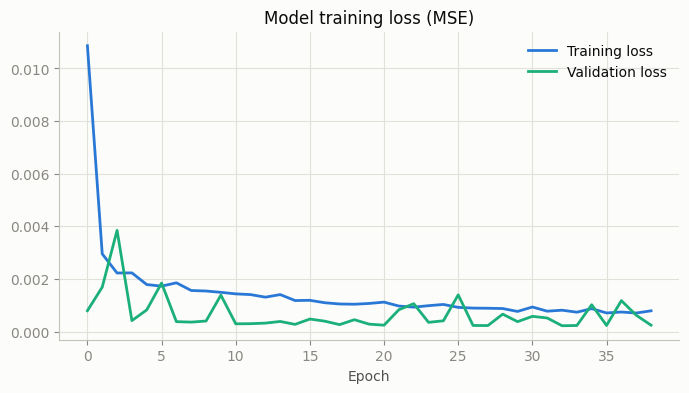

In [11]:
early_stop = EarlyStopping(monitor="val_loss", patience=6,
                           restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=40, batch_size=32,
                    validation_split=0.1, callbacks=[early_stop], verbose=2)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history["loss"], color=COLORS["blue"], label="Training loss")
ax.plot(history.history["val_loss"], color=COLORS["aqua"],
        label="Validation loss")
ax.set_title("Model training loss (MSE)")
ax.set_xlabel("Epoch")
ax.legend()
save_fig(fig, "04_training_loss.png")
plt.show()

## Task 5 — Prediction, Evaluation & 15-Step Forecast

Predictions are inverted back to dollar prices and compared against the
actual adjusted close. Performance is measured with the **R² score**
(`sklearn.metrics.r2_score`, the coefficient of determination).

In [12]:
pred_train = target_scaler.inverse_transform(
    model.predict(X_train, verbose=0)).ravel()
pred_test = target_scaler.inverse_transform(
    model.predict(X_test, verbose=0)).ravel()
true_train = target_scaler.inverse_transform(y_train.reshape(-1, 1)).ravel()
true_test = target_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()

r2_train = r2_score(true_train, pred_train)
r2_test = r2_score(true_test, pred_test)
print(f"R2 score (train): {r2_train:.4f}")
print(f"R2 score (test):  {r2_test:.4f}")

2026-07-05 03:11:29.435265: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


R2 score (train): 0.9956
R2 score (test):  0.8549


saved plot -> 05_actual_vs_predicted.png


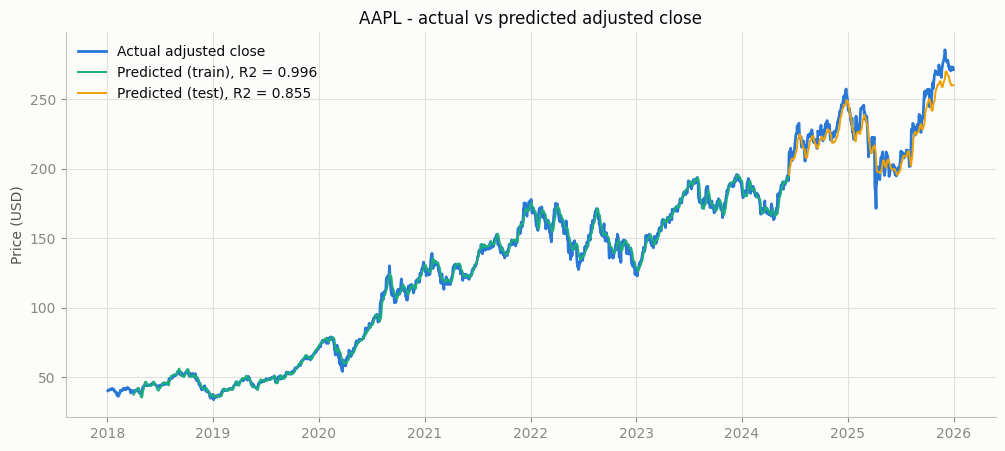

In [13]:
dates = data.index[WINDOW:]
fig, ax = plt.subplots()
ax.plot(data.index, data["Adj Close"], color=COLORS["blue"],
        label="Actual adjusted close")
ax.plot(dates[:split], pred_train, color=COLORS["aqua"], linewidth=1.4,
        label=f"Predicted (train), R2 = {r2_train:.3f}")
ax.plot(dates[split:], pred_test, color=COLORS["yellow"], linewidth=1.4,
        label=f"Predicted (test), R2 = {r2_test:.3f}")
ax.set_title(f"{TICKER} - actual vs predicted adjusted close")
ax.set_ylabel("Price (USD)")
ax.legend()
save_fig(fig, "05_actual_vs_predicted.png")
plt.show()

In [14]:
def forecast_future(steps=15):
    """Recursive multi-step forecast: each predicted close is appended to the
    price history and MACD/RSI are recomputed before the next step."""
    close = data["Adj Close"].copy()
    for _ in range(steps):
        macd, _, _ = compute_macd(close)
        rsi = compute_rsi(close)
        feats = pd.concat([close, macd, rsi], axis=1).iloc[-WINDOW:].values
        scaled = feature_scaler.transform(feats).reshape(1, WINDOW, -1)
        next_scaled = model.predict(scaled, verbose=0)[0, 0]
        next_price = target_scaler.inverse_transform([[next_scaled]])[0, 0]
        close.loc[close.index[-1] + pd.Timedelta(days=1)] = next_price

    step_offset = {"daily": pd.tseries.offsets.BDay(1),
                   "weekly": pd.DateOffset(weeks=1),
                   "monthly": pd.DateOffset(months=1)}[TIMEFRAME]
    future_dates = []
    date = data.index[-1]
    for _ in range(steps):
        date = date + step_offset
        future_dates.append(date)
    return pd.Series(close.values[-steps:], index=future_dates, name="Forecast")


forecast = forecast_future(steps=15)
print(f"Forecast for the next 15 {TIMEFRAME} units:")
forecast.round(2)

Forecast for the next 15 daily units:


2026-01-01    259.93
2026-01-02    257.62
2026-01-05    254.74
2026-01-06    251.62
2026-01-07    248.46
2026-01-08    245.34
2026-01-09    242.32
2026-01-12    239.41
2026-01-13    236.61
2026-01-14    233.93
2026-01-15    231.35
2026-01-16    228.85
2026-01-19    226.44
2026-01-20    224.10
2026-01-21    221.82
Name: Forecast, dtype: float64

saved plot -> 06_forecast.png


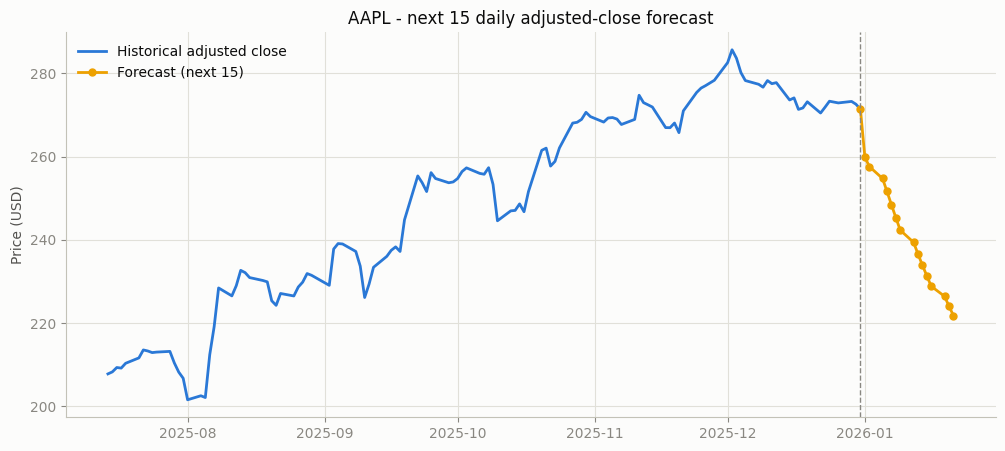

In [15]:
recent = data["Adj Close"].iloc[-120:]
fig, ax = plt.subplots()
ax.plot(recent.index, recent.values, color=COLORS["blue"],
        label="Historical adjusted close")
joined = pd.concat([recent.iloc[-1:], forecast])  # connect history to forecast
ax.plot(joined.index, joined.values, color=COLORS["yellow"], marker="o",
        markersize=5, label=f"Forecast (next {len(forecast)})")
ax.axvline(recent.index[-1], color="#898781", linewidth=1, linestyle="--")
ax.set_title(f"{TICKER} - next {len(forecast)} {TIMEFRAME} adjusted-close forecast")
ax.set_ylabel("Price (USD)")
ax.legend()
save_fig(fig, "06_forecast.png")
plt.show()

## Results & Conclusion

* The model tracks the held-out test period closely (R² printed above) —
  respectable for a compact LSTM given that the test window lies entirely in
  the model's future.
* The 15-step forecast is **recursive**: each prediction feeds back as input
  and the indicators are recomputed, so errors compound and the curve tends
  to drift toward recent trend/mean. This is a well-known limitation of
  single-output recursive forecasting; Part 2 can address it with
  direct multi-output heads or sequence-to-sequence models.